In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

class_names = ['Airplane',
               'Automobile',
               'Bird',
               'Cat',
               'Deer',
               'Dog',
               'Frog',
               'Horse',
               'Ship',
               'Truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1509s 9us/step


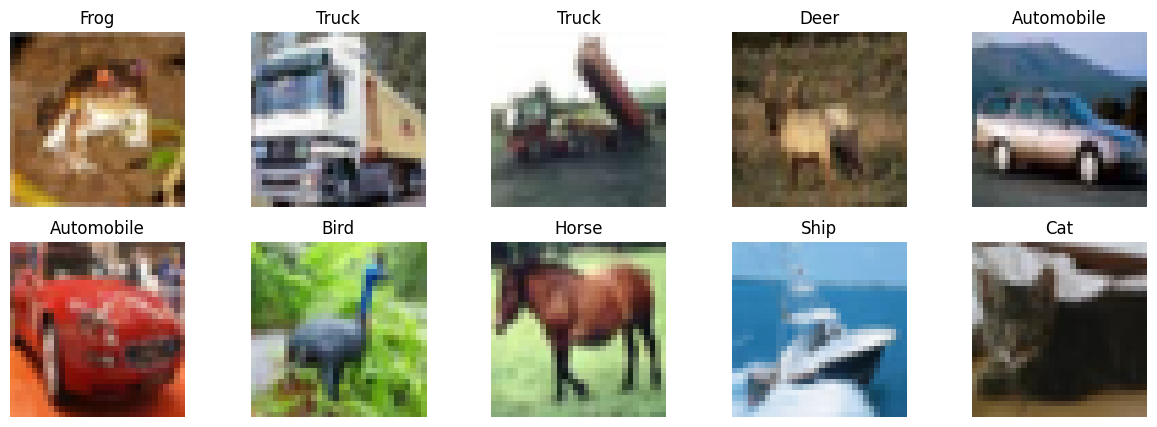

In [ ]:
plt.figure(figsize=(15,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

In [ ]:
print("Number of Classes :", len(class_names))

print("Image Size :", X_train.shape[1:])

print("Training Images :", X_train.shape[0])

print("Testing Images :", X_test.shape[0])

print("\nClass Names:")

for i,c in enumerate(class_names):
    print(i,"-",c)

Number of Classes : 10
Image Size : (32, 32, 3)
Training Images : 50000
Testing Images : 10000

Class Names:
0 - Airplane
1 - Automobile
2 - Bird
3 - Cat
4 - Deer
5 - Dog
6 - Frog
7 - Horse
8 - Ship
9 - Truck


In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [ ]:
print("X_train :",X_train.shape)
print("X_test :",X_test.shape)
print("y_train :",y_train.shape)
print("y_test :",y_test.shape)

X_train : (50000, 32, 32, 3)
X_test : (10000, 32, 32, 3)
y_train : (50000, 10)
y_test : (10000, 10)


In [ ]:
model = Sequential()

model.add(Conv2D(32,(3,3),
                 activation='relu',
                 input_shape=(32,32,3)))

model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.4456 - loss: 1.5381 - val_accuracy: 0.5407 - val_loss: 1.3079
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5871 - loss: 1.1732 - val_accuracy: 0.5935 - val_loss: 1.1751
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6399 - loss: 1.0326 - val_accuracy: 0.6409 - val_loss: 1.0306
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6759 - loss: 0.9344 - val_accuracy: 0.6662 - val_loss: 0.9625
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6998 - loss: 0.8618 - val_accuracy: 0.6637 - val_loss: 0.9659
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7225 - loss: 0.7978 - val_accuracy: 0.6882 - val_loss: 0.9140
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7458 - loss: 0.7359 - val_accuracy: 0.6829 - val_loss: 0.9238
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7629 - loss: 0.6793 - val_accuracy: 0.

In [ ]:
train_loss, train_acc = model.evaluate(X_train,y_train)

test_loss, test_acc = model.evaluate(X_test,y_test)

print("Training Accuracy :",train_acc)

print("Testing Accuracy :",test_acc)

print("Training Loss :",train_loss)

print("Testing Loss :",test_loss)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8889 - loss: 0.4394
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6720 - loss: 1.5222
Training Accuracy : 0.8888800144195557
Testing Accuracy : 0.671999990940094
Training Loss : 0.4393978416919708
Testing Loss : 1.5222467184066772


In [ ]:
if train_acc-test_acc > 0.10:
    print("Model is Overfitting")
elif train_acc<0.70 and test_acc<0.70:
    print("Model is Underfitting")
else:
    print("Model is Well Fitted")

Model is Overfitting


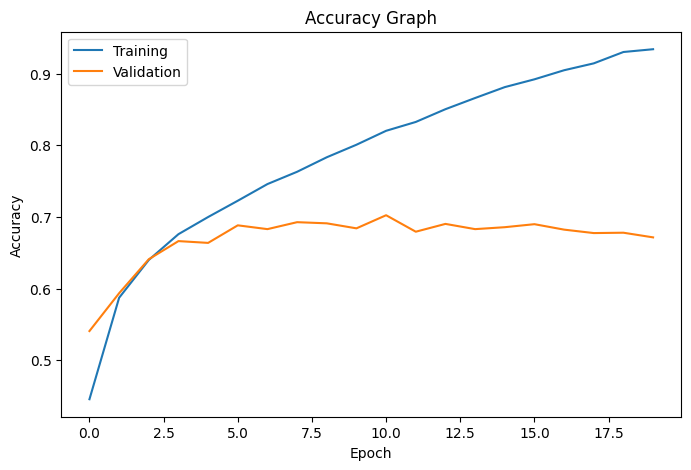

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Training')

plt.plot(history.history['val_accuracy'],label='Validation')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.title("Accuracy Graph")

plt.show()

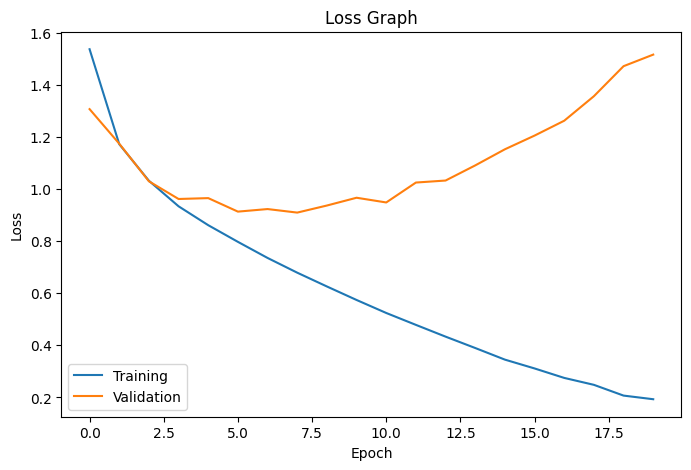

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Training')

plt.plot(history.history['val_loss'],label='Validation')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.title("Loss Graph")

plt.show()

In [ ]:
pred = model.predict(X_test)

pred = np.argmax(pred,axis=1)

actual = np.argmax(y_test,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


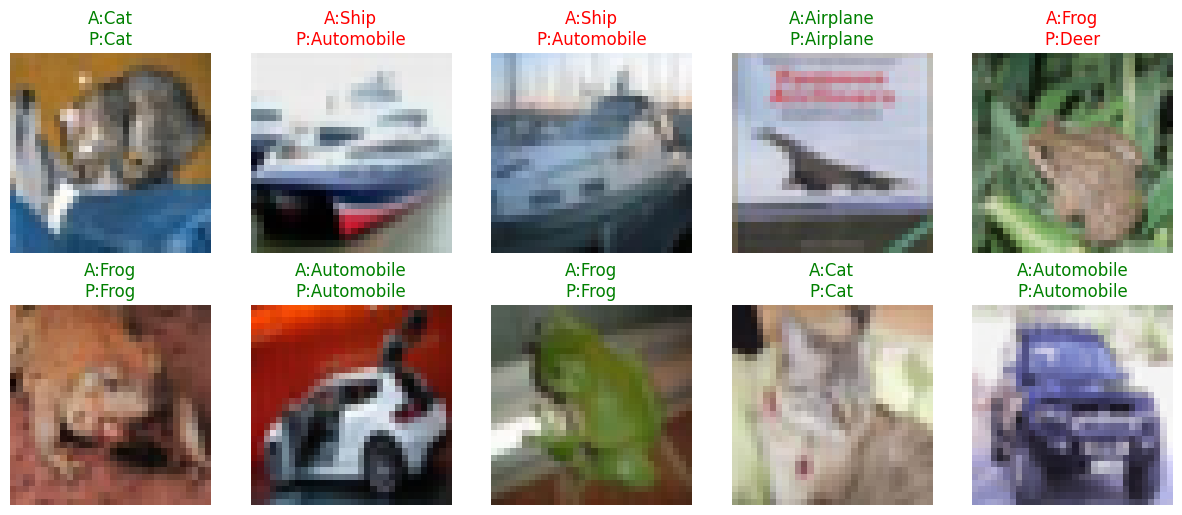

In [ ]:
plt.figure(figsize=(15,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i])

    if pred[i]==actual[i]:
        color="green"
    else:
        color="red"

    plt.title(f"A:{class_names[actual[i]]}\nP:{class_names[pred[i]]}",
              color=color)

    plt.axis("off")

plt.show()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
improved = Sequential()

improved.add(Conv2D(32,(3,3),
                    activation='relu',
                    input_shape=(32,32,3)))

improved.add(BatchNormalization())

improved.add(MaxPooling2D())

improved.add(Conv2D(64,(3,3),
                    activation='relu'))

improved.add(BatchNormalization())

improved.add(MaxPooling2D())

improved.add(Conv2D(128,(3,3),
                    activation='relu'))

improved.add(MaxPooling2D())

improved.add(Dropout(0.3))

improved.add(Flatten())

improved.add(Dense(256,activation='relu'))

improved.add(Dropout(0.5))

improved.add(Dense(10,activation='softmax'))

In [ ]:
improved.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history2 = improved.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=64,
    callbacks=[early]
)

Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3974 - loss: 1.6626 - val_accuracy: 0.4093 - val_loss: 1.6985
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5377 - loss: 1.3008 - val_accuracy: 0.2975 - val_loss: 1.9081
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5953 - loss: 1.1419 - val_accuracy: 0.5750 - val_loss: 1.2165
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6365 - loss: 1.0363 - val_accuracy: 0.6519 - val_loss: 0.9777
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6662 - loss: 0.9564 - val_accuracy: 0.6851 - val_loss: 0.9092
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6881 - loss: 0.8905 - val_accuracy: 0.6334 - val_loss: 1.0482
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7079 - loss: 0.8372 - val_accuracy: 0.7113 - val_loss: 0.8402
Epoch 8/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7227 - loss: 0.7932 - val_accuracy: 0

In [ ]:
old_acc = model.evaluate(X_test,y_test)[1]

new_acc = improved.evaluate(X_test,y_test)[1]

print("Old Accuracy :",old_acc)

print("New Accuracy :",new_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6720 - loss: 1.5222
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7084 - loss: 0.8527
Old Accuracy : 0.671999990940094
New Accuracy : 0.7084000110626221


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


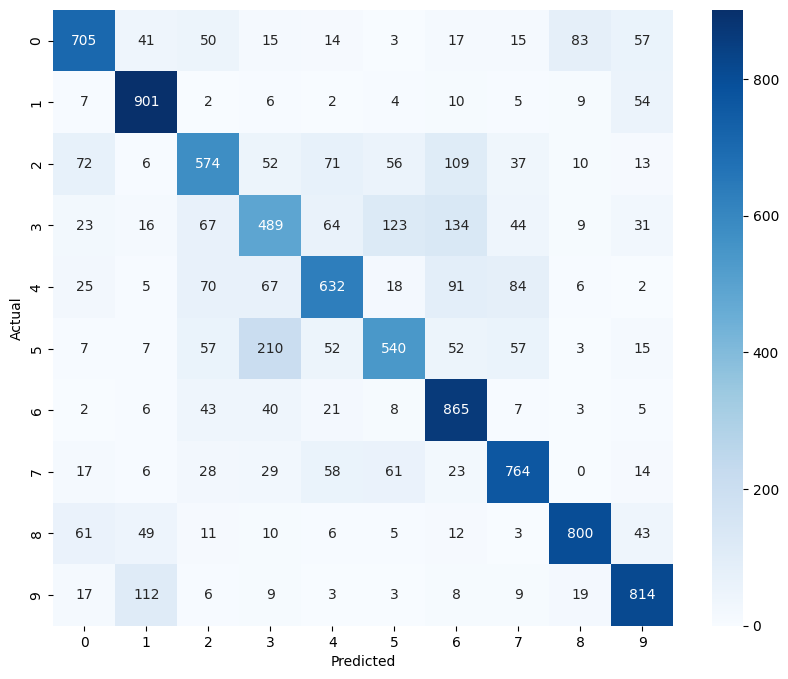

In [ ]:
pred = improved.predict(X_test)

pred = np.argmax(pred,axis=1)

actual = np.argmax(y_test,axis=1)

cm = confusion_matrix(actual,pred)

plt.figure(figsize=(10,8))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
print(classification_report(actual,
                            pred,
                            target_names=class_names))

              precision    recall  f1-score   support

    Airplane       0.75      0.70      0.73      1000
  Automobile       0.78      0.90      0.84      1000
        Bird       0.63      0.57      0.60      1000
         Cat       0.53      0.49      0.51      1000
        Deer       0.68      0.63      0.66      1000
         Dog       0.66      0.54      0.59      1000
        Frog       0.65      0.86      0.75      1000
       Horse       0.75      0.76      0.75      1000
        Ship       0.85      0.80      0.82      1000
       Truck       0.78      0.81      0.79      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.70     10000
weighted avg       0.71      0.71      0.70     10000



# Task 10: Model Analysis

## 1. Why is CNN preferred over ANN for image classification?

CNN is preferred over ANN because it automatically extracts important features such as edges, textures, and shapes from images using convolutional layers. It preserves the spatial relationship between pixels and requires fewer parameters than ANN, making it more efficient and accurate for image classification tasks.

---

## 2. What is the role of Conv2D?

The **Conv2D** layer applies multiple filters (kernels) to the input image to detect important features such as edges, corners, textures, and patterns. These extracted features help the model learn meaningful representations of the image.

---

## 3. Why is MaxPooling used?

**MaxPooling** reduces the size of the feature maps by selecting the maximum value from each region. This:
- Reduces computational complexity.
- Helps prevent overfitting.
- Retains the most important features.
- Makes the model more robust to small variations in the image.

---

## 4. Why is Flatten required?

The **Flatten** layer converts the two-dimensional feature maps generated by convolution and pooling layers into a one-dimensional vector. This allows the data to be passed to the fully connected (**Dense**) layers for final classification.

---

## 5. What does Softmax do?

The **Softmax** activation function converts the output values into probability scores for each class. The probabilities sum to 1, and the class with the highest probability is selected as the predicted class.

---

## 6. Which optimizer is used?

The model uses the **Adam Optimizer**. Adam combines the advantages of Momentum and RMSProp, providing faster convergence, adaptive learning rates, and efficient optimization for deep learning models.

---

## 7. Which loss function is used?

The loss function used is **Categorical Crossentropy**, which is suitable for multiclass classification problems where the class labels are one-hot encoded.

---

## 8. How can overfitting be reduced?

Overfitting can be reduced by using the following techniques:

- Adding **Dropout** layers.
- Using **Batch Normalization**.
- Applying **Data Augmentation**.
- Using **EarlyStopping** during training.
- Increasing the size and diversity of the training dataset.
- Applying **L2 Regularization (Weight Decay)**.
